In [11]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import scipy.stats as stats

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

weekly = (
    pd.read_csv("data/processed/weekly_load.csv", index_col=0, parse_dates=True)
      .squeeze("columns")      # DataFrame -> Series
)
weekly = weekly.asfreq("W")    # restore the weekly frequency on the index

TEST_WEEKS = 104
SEASONALITY = 52

DEFAULT_ORDER = (2, 1, 6)                 # match your Part 3 AIC-best
DEFAULT_SEASONAL_ORDER = (0, 1, 1, 52)
DEFAULT_EXOG = ["temp_mean", "heating_degree", "cooling_degree"]

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"

In [12]:
# ----------------------------------------------------------------------
# Reuse the Part 3 helpers so diagnostics/metrics are identical
# ----------------------------------------------------------------------

def residual_diagnostics(fit, lags=52, burn=SEASONALITY, path=None):
    """
    Assess model fit through the residuals:
      * residual ACF (should look like white noise -- no significant spikes),
      * residual distribution (histogram + QQ plot, should be ~Normal),
      * Ljung-Box test (H0: residuals are independent; want p > 0.05).

    The first `burn` residuals are dropped: seasonal differencing (D=1, s=52)
    produces a large diffuse-initialisation transient that is not informative.
    """
    resid = pd.Series(fit.resid).iloc[burn:]

    fig, ax = plt.subplots(2, 2, figsize=(13, 9))

    # (a) residuals over time
    ax[0, 0].plot(resid.index, resid.values, lw=0.8)
    ax[0, 0].axhline(0, color="k", lw=0.6)
    ax[0, 0].set_title("Residuals over time")

    # (b) residual ACF
    plot_acf(resid, lags=lags, ax=ax[0, 1])
    ax[0, 1].set_title("Residual ACF")

    # (c) histogram + normal curve
    ax[1, 0].hist(resid, bins=25, density=True, alpha=0.6, color="tab:blue")
    xs = np.linspace(resid.min(), resid.max(), 200)
    ax[1, 0].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()),
                  "r-", lw=1.5, label="Normal fit")
    ax[1, 0].set_title("Residual distribution")
    ax[1, 0].legend()

    # (d) QQ plot
    stats.probplot(resid, dist="norm", plot=ax[1, 1])
    ax[1, 1].set_title("Residual QQ plot")

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")

    lb = acorr_ljungbox(resid, lags=[12, 24, 52], return_df=True)
    jb_stat, jb_p = stats.jarque_bera(resid)[:2]
    summary = {
        "resid_mean": float(resid.mean()),
        "resid_std": float(resid.std()),
        "ljung_box": lb,                       # DataFrame of lb_stat / lb_pvalue
        "jarque_bera_stat": float(jb_stat),
        "jarque_bera_p": float(jb_p),
    }
    return summary, fig

def plot_forecast(train, test, mean, ci, path=None):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(train.index, train, color="tab:gray", lw=1, label="Train")
    ax.plot(test.index, test, color="black", lw=2, label="Test (actual)")
    ax.plot(mean.index, mean, color="tab:red", lw=1.8, label="SARIMA forecast")
    ax.fill_between(ci.index, ci["lower"], ci["upper"],
                    color="tab:red", alpha=0.15, label="95% CI")
    ax.axvline(test.index[0], color="k", lw=0.8, alpha=0.4)
    ax.set_title("SARIMA forecast -- weekly German load, 2-year horizon")
    ax.set_ylabel("Load (GW)")
    ax.set_xlabel("Date")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def evaluate(name, y_true, y_pred, y_train, seasonality=SEASONALITY):
    y_pred = y_pred.reindex(y_true.index)
    err = y_pred.to_numpy() - y_true.to_numpy()
    yt = y_train.to_numpy()
    scale = np.mean(np.abs(yt[seasonality:] - yt[:-seasonality]))
    return {
        "model": name,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MASE": float(np.mean(np.abs(err)) / scale),
        "Bias": float(np.mean(err)),
    }

def coverage(ci, y_true):
    inside = (y_true.to_numpy() >= ci["lower"].to_numpy()) & \
             (y_true.to_numpy() <= ci["upper"].to_numpy())
    return float(inside.mean())

In [13]:
# ----------------------------------------------------------------------
# 0. Timezone-safe index helper
# ----------------------------------------------------------------------

def _to_naive(idx) -> pd.DatetimeIndex:
    """Return a tz-naive DatetimeIndex (OPSD load is UTC-aware; temp is naive)."""
    idx = pd.DatetimeIndex(pd.to_datetime(idx))
    return idx.tz_localize(None) if idx.tz is not None else idx

In [14]:
# ----------------------------------------------------------------------
# 1. Temperature retrieval (Open-Meteo archive API)
# ----------------------------------------------------------------------

def get_open_meteo_temperature(
    start_date: str,
    end_date: str,
    latitude: float = 52.52,   # Berlin
    longitude: float = 13.41,
    cache_path: str | None = "data/processed/berlin_temp_daily.csv",
    max_retries: int = 3,
) -> pd.DataFrame:
    """
    Daily mean 2 m temperature for the given range. Cached to CSV so the API
    is only hit once. Retries with backoff on transient network errors.
    """
    if cache_path and os.path.exists(cache_path):
        return pd.read_csv(cache_path, index_col=0, parse_dates=True)

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    last_err = None
    for attempt in range(max_retries):
        try:
            resp = requests.get(ARCHIVE_URL, params=params, timeout=60)
            resp.raise_for_status()
            daily = resp.json()["daily"]
            temp = pd.DataFrame(
                {"temperature_2m_mean": daily["temperature_2m_mean"]},
                index=pd.to_datetime(daily["time"]),
            )
            temp.index.name = "date"
            if cache_path:
                os.makedirs(os.path.dirname(cache_path), exist_ok=True)
                temp.to_csv(cache_path)
            return temp
        except requests.RequestException as e:
            last_err = e
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    raise RuntimeError(f"Open-Meteo request failed after {max_retries} tries: {last_err}")

In [15]:
# ----------------------------------------------------------------------
# 2. Weekly temperature features aligned to the load index
# ----------------------------------------------------------------------

def build_weekly_temperature_features(
    temp_daily: pd.DataFrame,
    weekly_index: pd.DatetimeIndex,
    base_heat: float = 15.5,
    base_cool: float = 22.0,
) -> pd.DataFrame:
    """
    Resample daily temperature to weekly features on the SAME (week-ending
    Sunday) grid as the load series, then align to weekly_index.

    Features:
      temp_mean / temp_min / temp_max  -- weekly summary of daily mean temp
      heating_degree                   -- sum over the week of max(base_heat - T, 0)
      cooling_degree                   -- sum over the week of max(T - base_cool, 0)

    Heating/cooling degree days capture the U-shaped load-temperature response
    (demand rises in both cold and hot weeks).
    """
    t = temp_daily["temperature_2m_mean"].copy()
    t.index = _to_naive(t.index)

    feats = pd.DataFrame(index=None)
    feats = pd.DataFrame({
        "temp_mean": t.resample("W").mean(),
        "temp_min": t.resample("W").min(),
        "temp_max": t.resample("W").max(),
        "heating_degree": np.maximum(base_heat - t, 0).resample("W").sum(),
        "cooling_degree": np.maximum(t - base_cool, 0).resample("W").sum(),
    })

    feats = feats.reindex(_to_naive(weekly_index)).interpolate("time")
    feats.index = weekly_index          # restore original labels/tz
    return feats


def assemble_feature_df(weekly_load: pd.Series, temp_weekly: pd.DataFrame) -> pd.DataFrame:
    """Join load and temperature features on the weekly index; interpolate gaps."""
    df = pd.DataFrame({"load_gw": weekly_load})
    df = df.join(temp_weekly)
    return df.interpolate("time").dropna()

In [16]:
# ----------------------------------------------------------------------
# 3. SARIMAX with exogenous regressors
# ----------------------------------------------------------------------

def fit_sarimax(y_train, X_train, order=DEFAULT_ORDER,
                seasonal_order=DEFAULT_SEASONAL_ORDER):
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(
            y_train, exog=X_train, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)


def forecast_sarimax(fit, steps, X_test, index, alpha=0.05):
    """Conditional forecast: feeds observed test-period temperature as exog."""
    fc = fit.get_forecast(steps=steps, exog=X_test)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=alpha)
    mean.index = index
    ci.index = index
    ci.columns = ["lower", "upper"]
    return mean, ci

In [17]:
# ----------------------------------------------------------------------
# Orchestration
# ----------------------------------------------------------------------

def run_part4(
    weekly: pd.Series,
    test_weeks: int = TEST_WEEKS,
    order=DEFAULT_ORDER,
    seasonal_order=DEFAULT_SEASONAL_ORDER,
    exog_cols=DEFAULT_EXOG,
    seasonal_naive_rmse: float | None = None,   # pass your Part 2 value to compare
    sarima_rmse: float | None = None,           # pass your Part 3 value to compare
    save_dir: str | None = None,
):
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    weekly = weekly.copy()

    # --- temperature ---
    start = str(_to_naive(weekly.index).min().date())
    end = str(_to_naive(weekly.index).max().date())
    print(f"Fetching Berlin temperature {start} .. {end} ...")
    temp_daily = get_open_meteo_temperature(start_date=start, end_date=end)
    temp_weekly = build_weekly_temperature_features(temp_daily, weekly.index)

    feature_df = assemble_feature_df(weekly, temp_weekly)
    print(f"Feature frame: {feature_df.shape[0]} weeks, cols={list(feature_df.columns)}")
    print("Load-temperature correlation:\n",
          feature_df[["load_gw"] + exog_cols].corr()["load_gw"].round(3).to_string())

    # --- split (keep y and X aligned) ---
    y = feature_df["load_gw"]
    X = feature_df[exog_cols]
    y_train, y_test = y.iloc[:-test_weeks], y.iloc[-test_weeks:]
    X_train, X_test = X.iloc[:-test_weeks], X.iloc[-test_weeks:]

    # --- fit ---
    fit = fit_sarimax(y_train, X_train, order, seasonal_order)
    print(f"\nSARIMAX{order}x{seasonal_order} + {exog_cols}  AIC={fit.aic:.1f}")
    print("\nExogenous coefficients:")
    for c in exog_cols:
        if c in fit.params.index:
            print(f"  {c:16s} {fit.params[c]:+.4f}  (p={fit.pvalues[c]:.3f})")

    # --- diagnostics ---
    diag_path = os.path.join(save_dir, "sarimax_residuals.png") if save_dir else None
    diag, _ = residual_diagnostics(fit, path=diag_path)
    print("\nLjung-Box (want p > 0.05):")
    print(diag["ljung_box"].round(4).to_string())
    print(f"Jarque-Bera normality p = {diag['jarque_bera_p']:.4f}")

    # --- conditional forecast ---
    mean, ci = forecast_sarimax(fit, len(y_test), X_test, y_test.index)
    metrics = evaluate(f"SARIMAX(temp){order}x{seasonal_order}",
                       y_test, mean, y_train)
    print("\nConditional forecast accuracy (observed test temperature):")
    print(pd.DataFrame([metrics]).round(3).to_string(index=False))
    print(f"95% CI coverage on test: {coverage(ci, y_test):.1%}")

    # --- comparison ---
    comp = [metrics]
    if sarima_rmse is not None:
        comp.append({"model": "SARIMA (no exog, Part 3)", "RMSE": sarima_rmse})
    if seasonal_naive_rmse is not None:
        comp.append({"model": "seasonal naive (Part 2)", "RMSE": seasonal_naive_rmse})
    comp_df = pd.DataFrame(comp)[["model", "RMSE"]].sort_values("RMSE")
    print("\nRMSE comparison:")
    print(comp_df.round(3).to_string(index=False))

    if save_dir:
        out = pd.DataFrame({"actual": y_test, "forecast": mean,
                            "lower": ci["lower"], "upper": ci["upper"]})
        out.to_csv(os.path.join(save_dir, "sarimax_forecast.csv"))
        feature_df.to_csv(os.path.join(save_dir, "feature_df.csv"))
    plot_path = os.path.join(save_dir, "sarimax_forecast.png") if save_dir else None
    plot_forecast(y_train, y_test, mean, ci, path=plot_path)

    return fit, feature_df, metrics, (mean, ci)

Fetching Berlin temperature 2015-01-04 .. 2020-10-04 ...


Feature frame: 301 weeks, cols=['load_gw', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree', 'cooling_degree']
Load-temperature correlation:
 load_gw           1.000
temp_mean        -0.637
heating_degree    0.694
cooling_degree   -0.159

SARIMAX(2, 1, 6)x(0, 1, 1, 52) + ['temp_mean', 'heating_degree', 'cooling_degree']  AIC=290.0

Exogenous coefficients:
  temp_mean        +0.3274  (p=0.050)
  heating_degree   +0.0810  (p=0.001)
  cooling_degree   -0.0108  (p=0.884)

Ljung-Box (want p > 0.05):
    lb_stat  lb_pvalue
12  15.5796     0.2113
24  19.1871     0.7419
52  28.1221     0.9972
Jarque-Bera normality p = 0.0000

Conditional forecast accuracy (observed test temperature):
                               model   MAE  RMSE  MASE  Bias
SARIMAX(temp)(2, 1, 6)x(0, 1, 1, 52) 2.815 3.553 2.103 2.521
95% CI coverage on test: 51.0%

RMSE comparison:
                               model  RMSE
             seasonal naive (Part 2) 3.007
SARIMAX(temp)(2, 1, 6)x(0, 1, 1, 52) 3.553
          

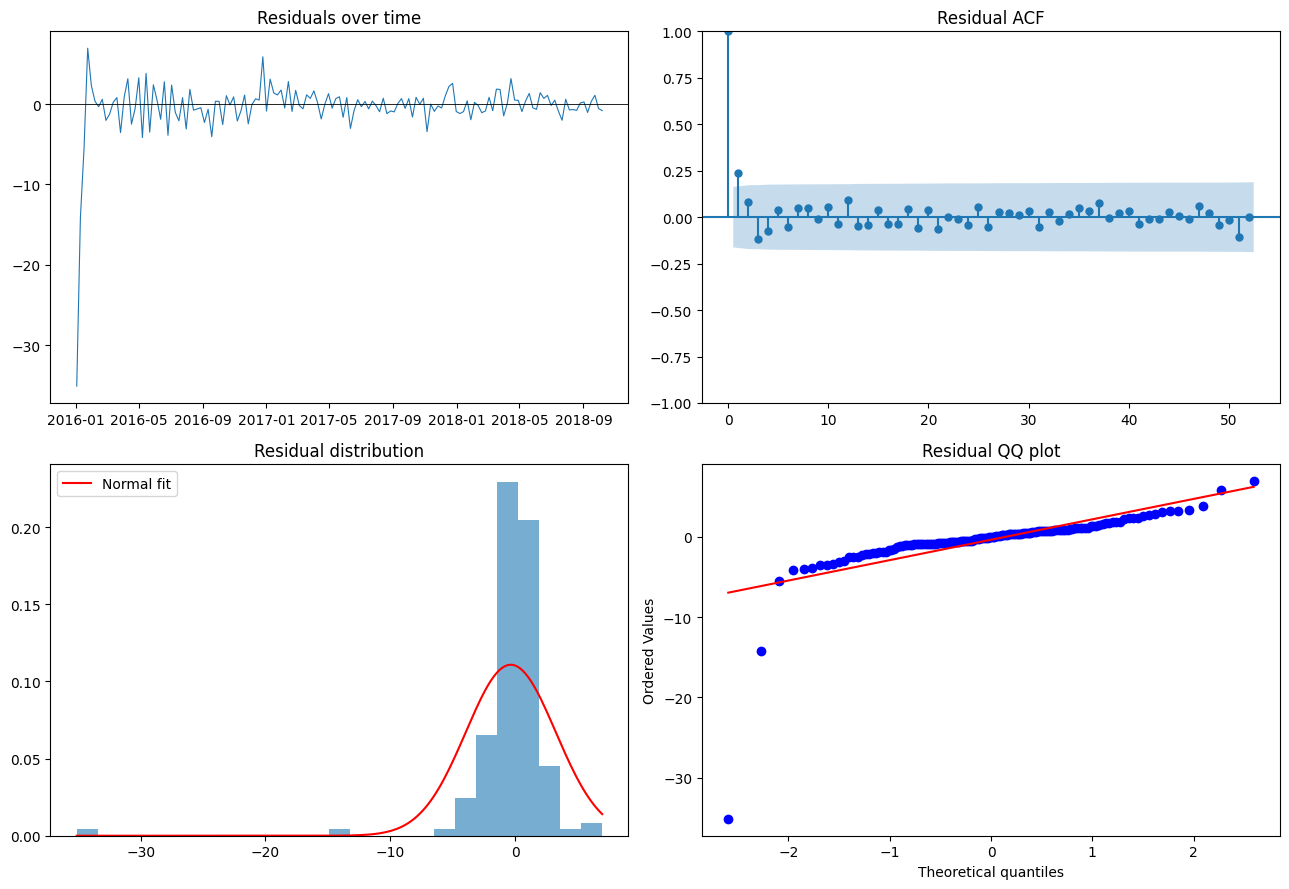

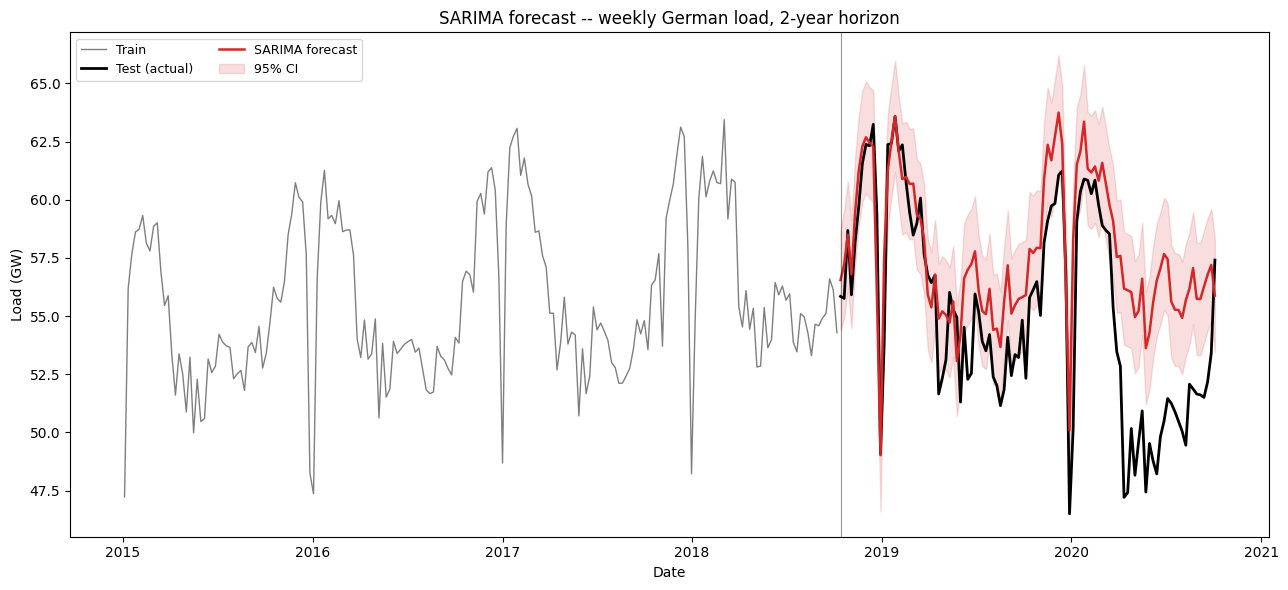

In [18]:
fit, feature_df, metrics, (mean, ci) = run_part4(
    weekly,
    order=(2, 1, 6),                    # same order as your Part 3, for a fair comparison
    seasonal_naive_rmse=3.007,          # your Part 2 number
    sarima_rmse=3.762,                  # your Part 3 number
    save_dir="outputs/04",
)